# Analisys of the generated data

## DeepSeek-R1-Distill-Qwen-1.5B

https://huggingface.co/deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B

1. real
2. baseline
3. targeted + linguistic tags
4. unsupervised context

In [1]:
import os
import re

# CHANGE WORKING DIRECTORY TO ROOT
current_dir = os.path.basename(os.getcwd())
if current_dir == "src":
    os.chdir("..") # Move up by 1
elif os.path.basename(os.getcwd()) == "bai-thesis-nlp":  
    pass # If already at root, stay there
else:
    os.chdir("../..") # Move up by 2 otherwise

import pandas as pd
from src._utils._helpers import get_generated_examples_df
from src._utils._data_analysis_helpers import basic_analysis, check_patterns

analysis_result = []

DATASET = "agnews"
SYN_DATA_DIR = "synthetic_data/datasets/DeepSeek-R1-Distill-Qwen-1.5B/"

# 1. Real data

REAL DATA


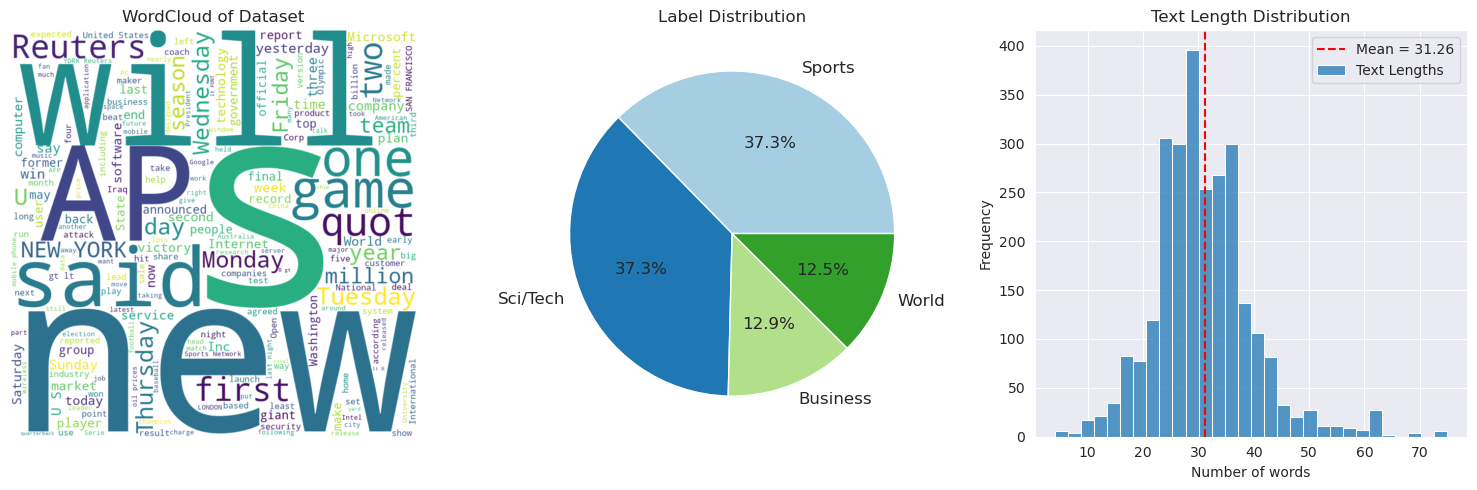

Number of train samples: 2679
Set of labels: {'Sci/Tech', 'Sports', 'World', 'Business'}
Number of labels: 4


In [2]:
print("REAL DATA")
df_real = pd.read_csv("real_data/train/"+DATASET+"trainAll.csv")
df_real = df_real.rename(columns={"2": "text", "3": "label"})
basic_analysis(df_real, print_count_statistics=False, print_missing_values=False)

In [3]:
analysis_result.append(check_patterns(df_real, print_n=3, dataset_name="real"))

Percentage of documents starting with 'A ': 2.91%
Examples:
- A scientific dig has uncovered four pomegranates believed to be 2,500 years old preserved inside a woven basket nestled in a bronze vessel, a Greek archaeologist said Friday.
- A day before federal regulators are expected to free VoIP providers from state taxes, two California cities want their cut.
- A New York City group creates a kit so that anyone with an old computer can create a wireless access point.

Percentage of documents containing 'World Cup': 1.08%
Examples:
- On a clear day, you can see the Chateau Frontenac in Quebec City from her home in Chateau-Richer. But one day, nine years ago, a young volunteer working at a World Cup 
- In LONDON story headlined  quot;Van Nistelrooy plays down hip injury quot;, please read in intro ... World Cup qualifying win ... instead of ... friendly win ... correcting status of match. LONDON, Nov 18 (Reuters) - Manchester 
- Ireland held host France to a 0-0 draw Saturday in a World

# 2. synthetic baseline

In [4]:
path = SYN_DATA_DIR+DATASET+"_baseline_500.json"
df_baseline, metadata = get_generated_examples_df(path)
display(df_baseline.head())
print("Columns :", df_baseline.columns.to_list())
print("Labels  :", df_baseline['label'].unique())

,text,label
0,A major tech company has launched a new produc...,Sci/Tech
1,A local business is raising funds for a new in...,Business
2,A new AI-powered sports analytics tool has bee...,Sports
3,World record holders are being celebrated as a...,World
4,A global health incident has caused a noticeab...,World


Columns : ['text', 'label']
Labels  : ['Sci/Tech' 'Business' 'Sports' 'World']


RANDOM GENERATION


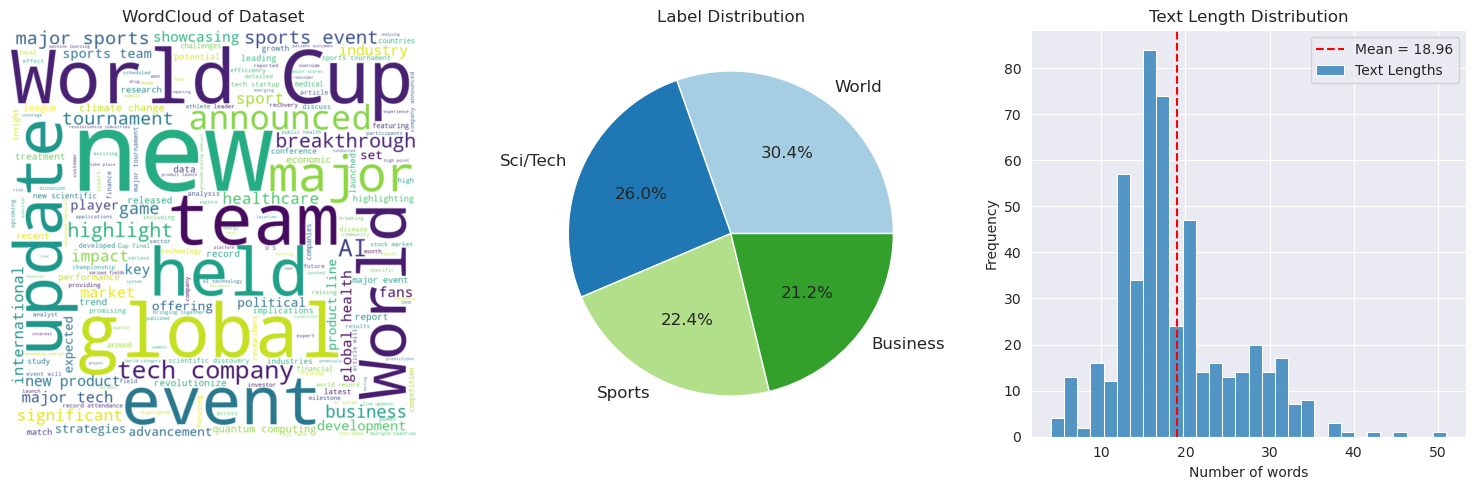

Number of train samples: 500
Set of labels: {'Sci/Tech', 'Sports', 'World', 'Business'}
Number of labels: 4


In [5]:
print("RANDOM GENERATION")
basic_analysis(df_baseline, print_count_statistics=False, print_missing_values=False)

In [6]:
analysis_result.append(check_patterns(df_baseline, print_n=3, dataset_name="baseline"))

Percentage of documents starting with 'A ': 67.20%
Examples:
- A major tech company has launched a new product line aimed at boosting employee engagement.
- A local business is raising funds for a new infrastructure project, which is expected to improve traffic efficiency.
- A new AI-powered sports analytics tool has been developed to optimize training strategies for competitive athletes.

Percentage of documents containing 'World Cup': 13.60%
Examples:
- The World Cup 2023 was held in a new location, with the tournament being held in multiple countries simultaneously.
- A major sports event, such as the World Cup final, was live-streamed and viewed by millions globally.
- The World Cup 2023 was held in three new countries, making it the most diverse World Cup yet.

Percentage of documents containing 'AI': 10.80%
Examples:
- A new AI-powered sports analytics tool has been developed to optimize training strategies for competitive athletes.
- A major tech company announced a breakthrough

# 3. synthetic targeted + tags

In [7]:
path = SYN_DATA_DIR+DATASET+"_targeted+tags_500.json"
df_targeted1, metadata = get_generated_examples_df(path)
path = SYN_DATA_DIR+DATASET+"_targeted+tags_500_2.json"
df_targeted2, metadata = get_generated_examples_df(path)
df_targeted = pd.concat([df_targeted1, df_targeted2], ignore_index=True)
display(df_targeted.head())
print("Columns :", df_targeted.columns.to_list())
print("Labels  :", df_targeted['label'].unique())

,text,label,phenomena
0,A startup is developing a new product that aim...,Business,"[Market strategy, Company strategy]"
1,"AI advancements are transforming healthcare, i...",Sci/Tech,"[AI, Biotech]"
2,The Olympics are a global event that highlight...,Sports,"[Events, Records, Highlights]"
3,The 2024 PyeongChang Olympics sparked tensions...,World,"[Conflicts, Trade, Politics]"
4,A global trade agreement aims to stabilize the...,Business,"[Economy, Regulations]"


Columns : ['text', 'label', 'phenomena']
Labels  : ['Business' 'Sci/Tech' 'Sports' 'World']


TARGETED GENERATION


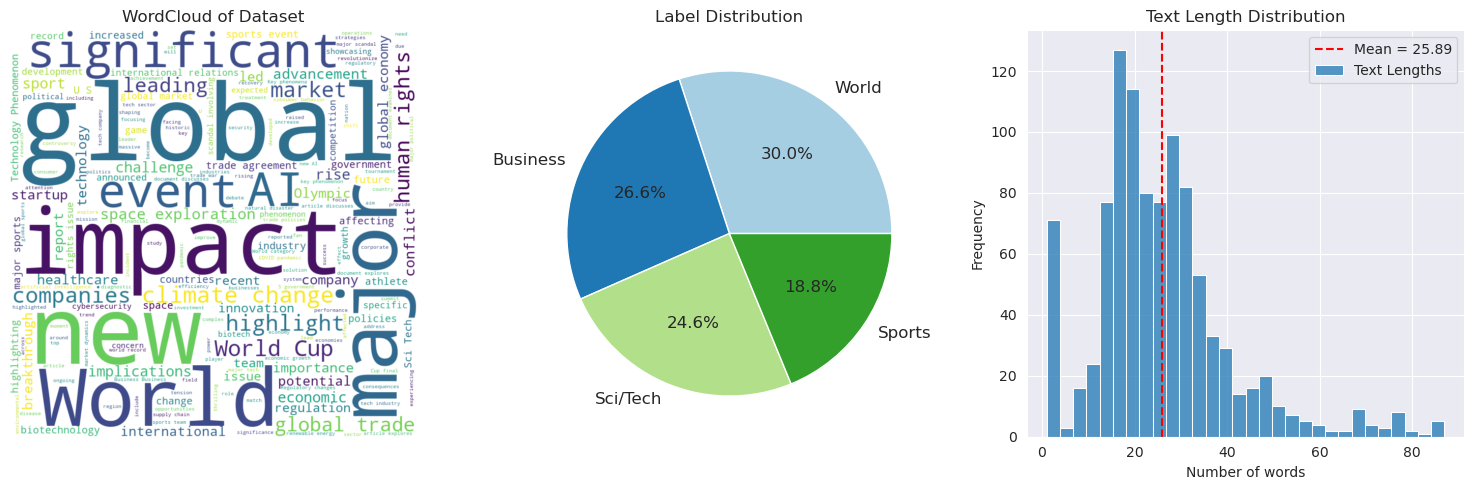

Number of train samples: 1000
Set of labels: {'Sci/Tech', 'Sports', 'World', 'Business'}
Number of labels: 4


In [8]:
print("TARGETED GENERATION")
basic_analysis(df_targeted, print_count_statistics=False, print_missing_values=False)

In [9]:
analysis_result.append(check_patterns(df_targeted, print_n=3, dataset_name="targeted+tags"))

Percentage of documents starting with 'A ': 32.70%
Examples:
- A startup is developing a new product that aims to disrupt the market, focusing on creating a competitive advantage through innovation.
- A global trade agreement aims to stabilize the economy by promoting sustainable practices, which could impact corporate profits and market dynamics.
- A scandal involving an Olympic athlete exposes the unfairness of the sport's grading system, affecting athletes' competitive performance.

Percentage of documents containing 'World Cup': 7.80%
Examples:
- The World Cup 2022 is a major event that showcases the global sports scene. Highlighting the final match between Germany and France, the tournament highlights the passion and skill of athletes. This is a significant event in the Sports category.
- A major world cup match was live-streamed live, showcasing the explosive growth of online sports entertainment.
- The 2022 World Cup had a massive impact on global markets. Matches were played re

Number of unique phenomena: 1663


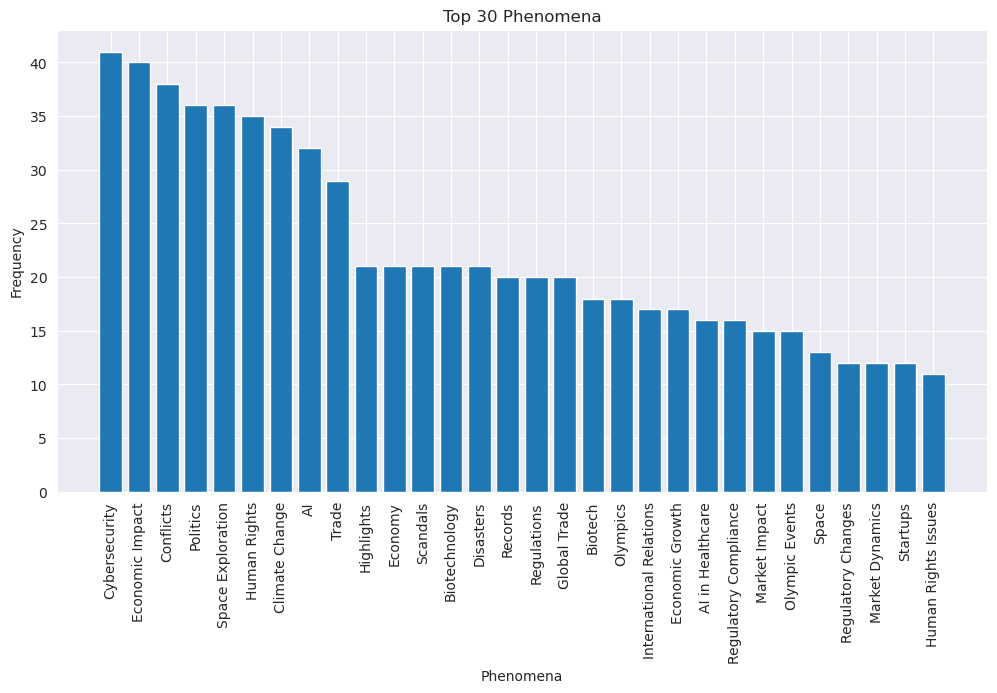

In [10]:
from collections import Counter
import matplotlib.pyplot as plt

# Extract all phenomena into a single list
all_phenomena = [phenomenon for sublist in df_targeted['phenomena'] for phenomenon in sublist]
phenomena_counts = Counter(all_phenomena)
print(f"Number of unique phenomena: {len(phenomena_counts)}")

# plot top n phenomena
n = 30
top_phenomena = phenomena_counts.most_common(n)

plt.figure(figsize=(12, 6))
plt.bar([phenomenon for phenomenon, count in top_phenomena], [count for phenomenon, count in top_phenomena])
plt.xlabel('Phenomena')
plt.ylabel('Frequency')
plt.title(f'Top {n} Phenomena')
plt.xticks(rotation=90)
plt.show()

# 4. Synthetic unsupervised context

In [11]:
path = SYN_DATA_DIR+DATASET+"_unsupervisedContext_500.json"
df_unsupContext, metadata = get_generated_examples_df(path)
display(df_unsupContext.head())
print("Columns :", df_unsupContext.columns.to_list())
print("Labels  :", df_unsupContext['label'].unique())

,text,label,context_examples
0,"In a landmark decision, the UK government has ...",World,"[&lt;strong&gt;Letters&lt;/strong&gt; Oh, and ..."
1,A new AI-powered platform is launching to revo...,Sci/Tech,[It is well known that Brett Favre doesn #39;t...
2,Brazil and Russia have once again reached the ...,Sports,[Johnny Cash''s instruments and possessions ra...
3,Global climate change has caused rising temper...,World,"[AP - In a fitting end to the PGA Tour season,..."
4,A groundbreaking AI system has been developed ...,Sci/Tech,[Trend Micro will become the latest major anti...


Columns : ['text', 'label', 'context_examples']
Labels  : ['World' 'Sci/Tech' 'Sports' 'Business']


UNSUPERVISED CONTEXT


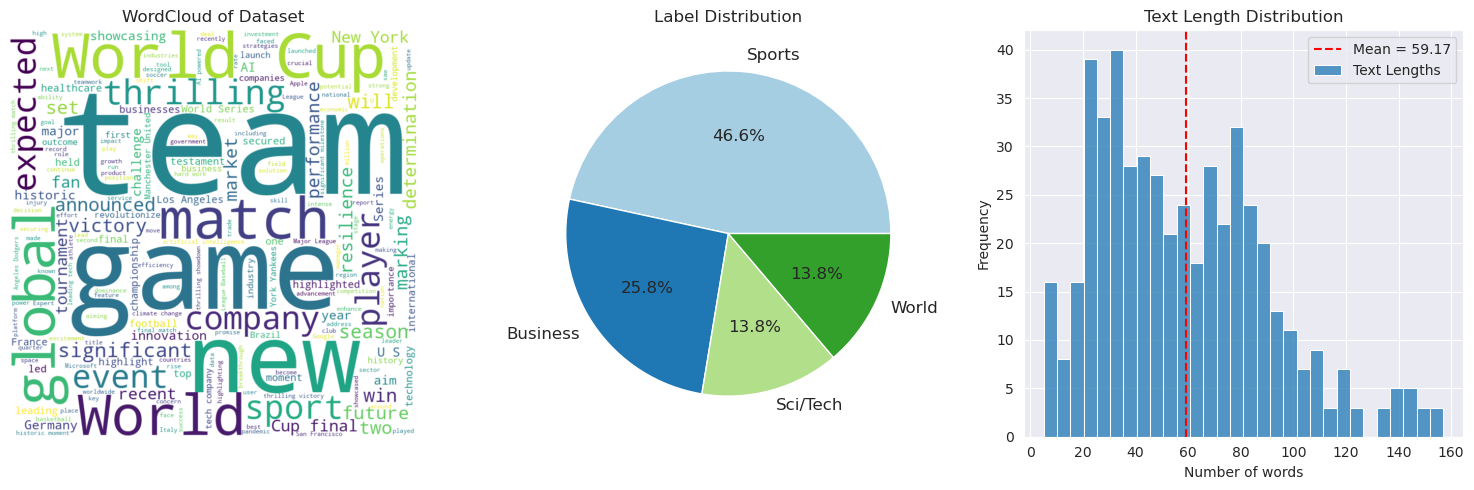

Number of train samples: 500
Set of labels: {'Sci/Tech', 'Sports', 'World', 'Business'}
Number of labels: 4


In [12]:
print("UNSUPERVISED CONTEXT")
basic_analysis(df_unsupContext, print_count_statistics=False, print_missing_values=False)

In [13]:
analysis_result.append(check_patterns(df_unsupContext, print_n=3, dataset_name="unsupervisedContext"))

Percentage of documents starting with 'A ': 11.40%
Examples:
- A new AI-powered platform is launching to revolutionize healthcare diagnostics. This breakthrough could transform how diseases are diagnosed and treated.
- A groundbreaking AI system has been developed to detect fraud with unprecedented accuracy. This new system, known as AI-Fixer, uses advanced machine learning algorithms to identify fraudulent activities in real-time. It has the potential to revolutionize industries such as finance, retail, and healthcare by reducing detection errors. The system operates by analyzing vast amounts of data, including transaction history, user behavior, and transaction details. It has already proven effective in detecting fraudulent transactions in retail, where it has reduced fraud rates by 30% compared to traditional methods. This development could lead to significant improvements in cybersecurity and enhance the overall efficiency of fraud detection systems.
- A leading tech company repor

Deeper analysis of the "world cup" phenomenon

In [14]:
# Display some examples containing "world cup" in the "text" field from all available dataframes
mask = df_unsupContext['text'].str.contains(r'world cup', case=False, na=False)
n_examples = 3
examples = df_unsupContext[mask].head(n_examples)
for index, row in examples.iterrows():
    print(f"TEXT: {row['text']}")
    print(f"LABEL: {row['label']}")

    # Count context examples containing "world cup"
    context_with_world_cup = [ctx for ctx in row['context_examples'] if re.search(r'world cup', ctx, re.IGNORECASE)]
    print(f"Number of context examples containing 'world cup': {len(context_with_world_cup)}")
    print("CONTEXT EXAMPLES:")
    for context_example in row['context_examples']:
        print(f"- {context_example}")
    print("-" * 50)

TEXT: Brazil and Russia have once again reached the World Cup final match, with Brazil emerging victorious in their clash against Russia. Highlighting the significance of the match, the Brazilian player Luiz Inui da Silva demonstrated his dominance with a stunning 91st-minute goal, while Russia's Ivanov also made a significant impact with a 29th-minute late winner. The match was a thrilling encounter, showcasing the talent of both teams and their ability to adapt under pressure.
LABEL: Sports
Number of context examples containing 'world cup': 0
CONTEXT EXAMPLES:
- Johnny Cash''s instruments and possessions raise almost \$4m (2.2) after a three-day auction in New York.
- com. Thome has known Charlie Manuel for his entire professional baseball life, which started shortly after he became a 13th-round draft pick by the Cleveland Indians in 1989.
- Auburn Hills - (11/29/04)--Auburn Hills police say they have identified the chair thrower from the Pistons/Pacers brawl. The suspect who alleged


---

# Comparison

In [15]:
df_analysis = pd.DataFrame(analysis_result)

display(df_analysis.round(2))

,dataset_name,n_documents,avg_length,starts_with_A_,world_cup,ai,world_in_non_world_label,non_latin
0,real,2679,31.26,2.91,1.08,0.0,5.75,0.0
1,baseline,500,18.96,67.20,13.60,10.8,8.00,0.4
2,targeted+tags,1000,25.89,32.70,7.80,11.9,10.10,0.1
3,unsupervisedContext,500,59.17,11.40,16.60,10.4,27.00,1.8


Columns meaning memo:
- `starts_with_A_`: % of docs starting with 'A '
- `world_cup`: % of docs containing 'world cup' 
- `ai`: % of docs containing 'ai' 
- `world_in_non_world_label`: % of docs containing 'world', but with the label != 'World'
- `non_latin`: % of docs containing non-latin characters

analysis unsupervised context
- the mean length of the documents is longer (of both the synthetic data generated in the other ways, but also the original one)
- the number of 'Sci/Tech' labels is much lower wrt the other ones
- the number of documents starting with 'A ' decreased, but is still high
- number of docs containing 'World Cup' increased. without any clear reason, the context given as example usually doesn't contain the word "world cup", since is quite rare in the whole real dataset
- number of docs containing 'AI' decreased
- the word 'world' appears a lot, also in non-World documents